[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunnel-ai/way/blob/main/notebooks/03_aux_trees_intuition.ipynb)

# Decision trees and random forests: a visual walkthrough

Companion to the classification module. The goal is to *see* what a decision tree actually does, why a single tree is unstable, and what changes when you average many of them.

We use a tiny 2D toy dataset (two interleaving half-moons) so we can draw the decision boundary at every step. None of this is fraud-related. The point is mechanism, not realism.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

RANDOM_STATE = 1955
np.random.seed(RANDOM_STATE)

## The dataset

`make_moons` generates two interleaving half-circles. No straight line separates the classes, so a linear model would struggle here. That's the whole point: trees and forests can carve up space with non-linear boundaries.

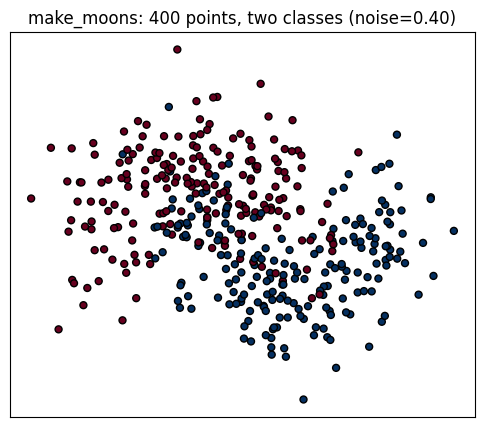

In [10]:
X, y = make_moons(n_samples=400, noise=0.40, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=25)
plt.title("make_moons: 400 points, two classes (noise=0.40)")
plt.xticks([]); plt.yticks([])
plt.show()

## A helper, then a single split

Below is a small helper that draws a model's decision regions. We will reuse it for every fit so the cells stay short.

A decision tree with `max_depth=1` is allowed exactly one yes/no question. It will pick the single feature and threshold that best separates the classes. The boundary is one straight cut.

train acc: 0.804   val acc: 0.733


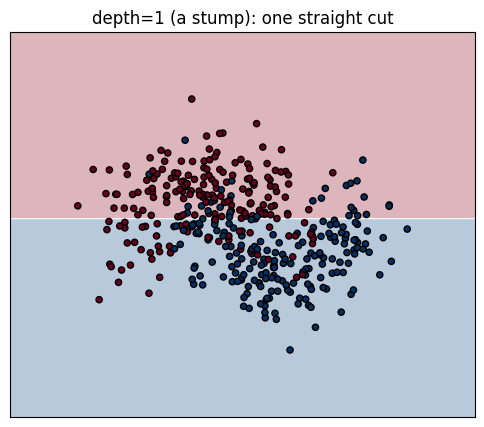

In [11]:
def plot_decision(model, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    DecisionBoundaryDisplay.from_estimator(
        model, X, ax=ax, alpha=0.3, cmap="RdBu", grid_resolution=200
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
stump.fit(X_train, y_train)
print(f"train acc: {stump.score(X_train, y_train):.3f}   val acc: {stump.score(X_val, y_val):.3f}")
plot_decision(stump, "depth=1 (a stump): one straight cut")
plt.show()

## Going deeper

Each additional level lets the tree make more cuts. The boundary becomes a stack of axis-aligned rectangles. With enough depth those rectangles become small enough to memorize the training data point by point.

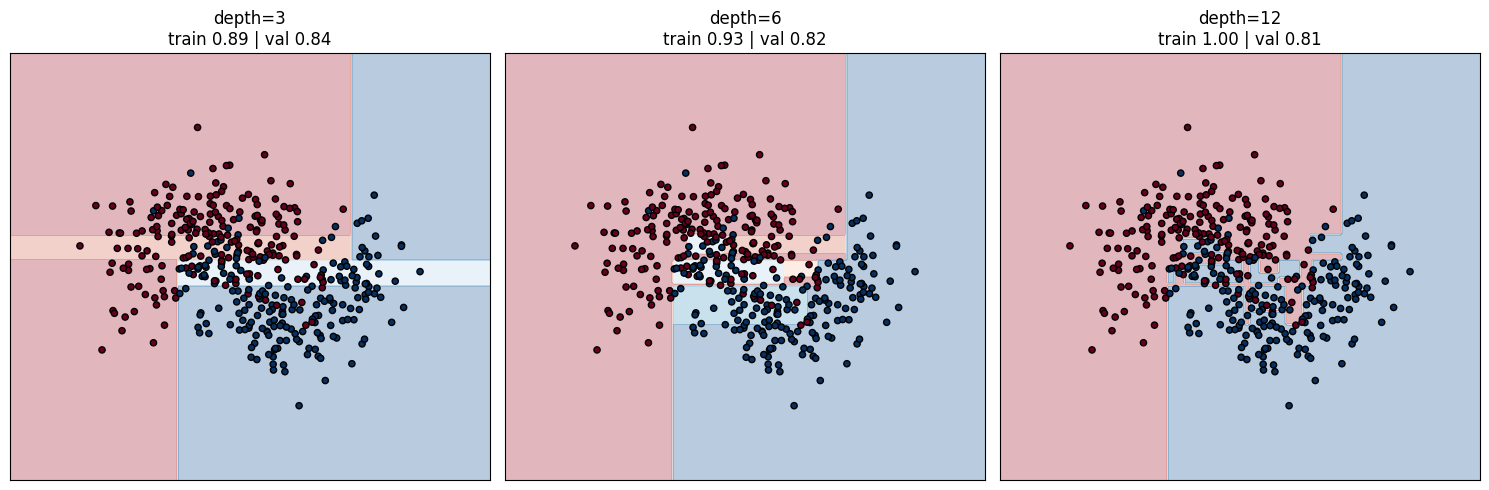

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, d in zip(axes, [3, 6, 12]):
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    val_acc = tree.score(X_val, y_val)
    plot_decision(tree, f"depth={d}\ntrain {train_acc:.2f} | val {val_acc:.2f}", ax=ax)

plt.tight_layout()
plt.show()

## The overfitting curve

Sweep depth from 1 to 15. Train accuracy climbs to 1.0 (perfect memorization). Validation accuracy peaks at some moderate depth and then drops as the tree fits noise. The gap between the two curves is the visual definition of overfitting.

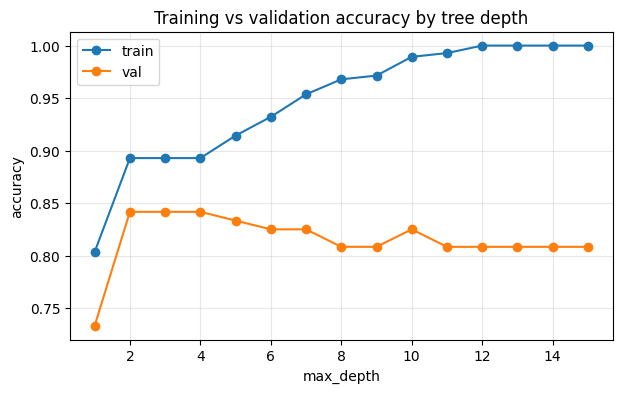

In [13]:
depths = range(1, 16)
train_scores, val_scores = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_scores.append(t.score(X_train, y_train))
    val_scores.append(t.score(X_val, y_val))

plt.figure(figsize=(7, 4))
plt.plot(list(depths), train_scores, marker="o", label="train")
plt.plot(list(depths), val_scores, marker="o", label="val")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Training vs validation accuracy by tree depth")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## What is "the tree," really?

`plot_tree` shows the actual structure. Each internal node asks one threshold question on one feature; each leaf assigns a class. There is no math beyond comparisons. Below is the depth-3 tree fit to this data, small enough to read.

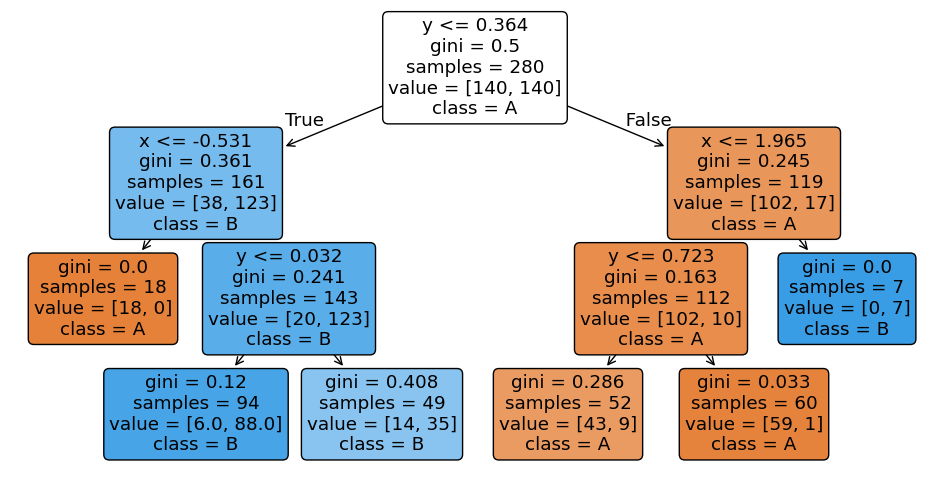

In [14]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
small_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(
    small_tree,
    filled=True,
    feature_names=["x", "y"],
    class_names=["A", "B"],
    rounded=True,
    ax=ax,
)
plt.show()

## Random forest: average many trees

A single deep tree is jagged and unstable. Two trees fit on slightly different samples will produce different boundaries (high variance). A *random forest* fits many trees, each on a bootstrap sample of the data and a random subset of features per split, and averages their predictions. Variance gets averaged away. Bias does not. The result is a smoother, more stable boundary.

train acc: 1.000   val acc: 0.850


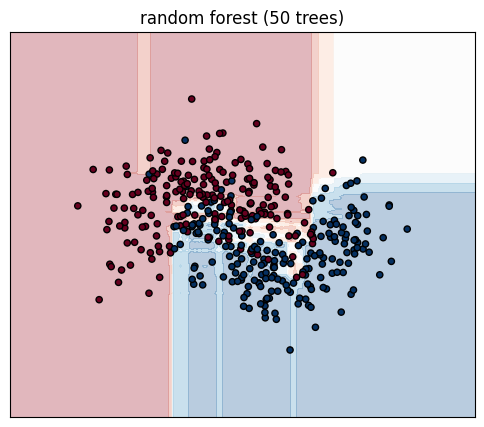

In [15]:
forest = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
forest.fit(X_train, y_train)

print(f"train acc: {forest.score(X_train, y_train):.3f}   val acc: {forest.score(X_val, y_val):.3f}")
plot_decision(forest, "random forest (50 trees)")
plt.show()

## Side-by-side: the failure forests fix

(say that 5 times fast...)

The same data, fit two ways. Left: a single tree at `max_depth=12`, jagged and clearly overfit. Right: 50 trees averaged. The ensemble's boundary smooths out the per-tree noise without losing the moon shape.

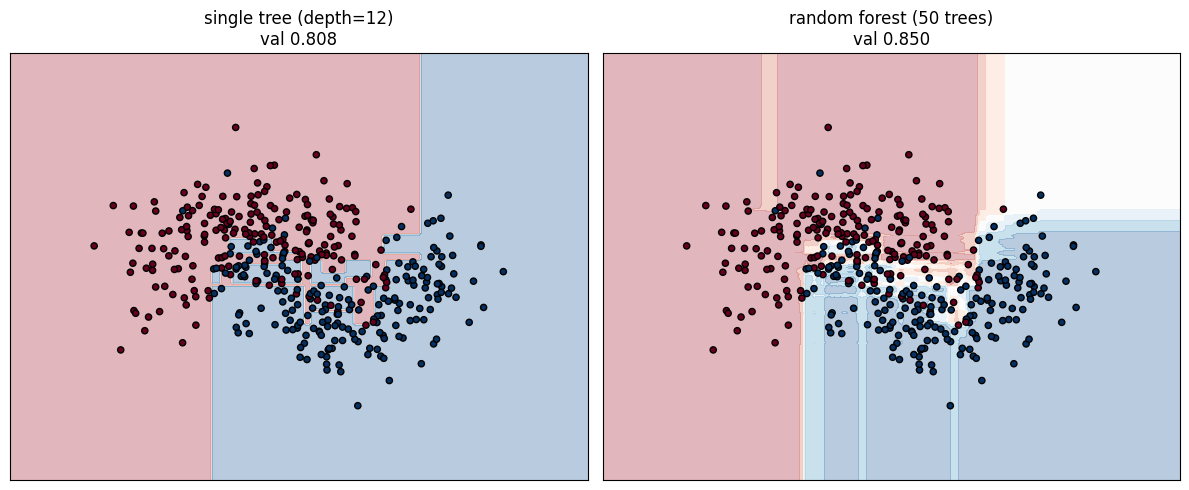

In [16]:
deep_tree = DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision(deep_tree, f"single tree (depth=12)\nval {deep_tree.score(X_val, y_val):.3f}", ax=axes[0])
plot_decision(forest,    f"random forest (50 trees)\nval {forest.score(X_val, y_val):.3f}",    ax=axes[1])
plt.tight_layout(); plt.show()

## Stability across splits

A single side-by-side is one snapshot. To see the more general argument for forests, fit both models on 15 different random train/val splits and look at the spread of validation accuracies.

What you'll see is not that the forest's box is *narrower* (it isn't, much: most of the val variance comes from which points happened to land in val, and that hits both models the same way). What you'll see is that the forest's whole box sits clearly above the single tree's. The forest's *worst* run is about as good as the deep tree's *median* run. Forests don't really shrink variance across splits; they lift the entire accuracy distribution.


/var/folders/jj/vhzjgmld30s622_zd423wg8867f3y5/T/ipykernel_37299/2843131211.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([deep_tree_scores, forest_scores], labels=["single deep tree", "forest (50 trees)"])


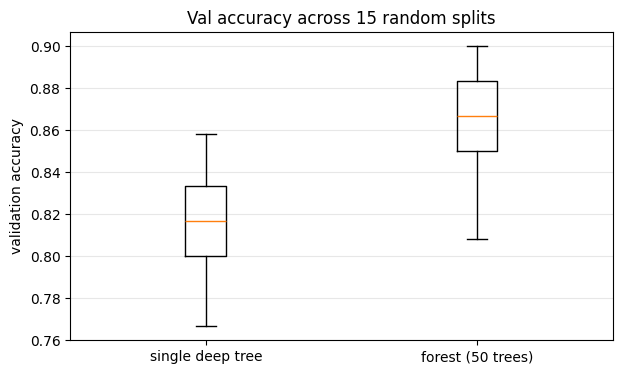

,model,mean,std,min,max
0,deep tree (depth=12),0.817,0.026,0.767,0.858
1,random forest (50 trees),0.863,0.025,0.808,0.900


In [17]:
n_runs = 15
deep_tree_scores = []
forest_scores = []

for seed in range(n_runs):
    Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)
    dt = DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE).fit(Xt, yt)
    rf = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE).fit(Xt, yt)
    deep_tree_scores.append(dt.score(Xv, yv))
    forest_scores.append(rf.score(Xv, yv))

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([deep_tree_scores, forest_scores], labels=["single deep tree", "forest (50 trees)"])
ax.set_ylabel("validation accuracy")
ax.set_title(f"Val accuracy across {n_runs} random splits")
ax.grid(alpha=0.3, axis="y")
plt.show()

pd.DataFrame({
    "model": ["deep tree (depth=12)", "random forest (50 trees)"],
    "mean": [np.mean(deep_tree_scores), np.mean(forest_scores)],
    "std":  [np.std(deep_tree_scores),  np.std(forest_scores)],
    "min":  [np.min(deep_tree_scores),  np.min(forest_scores)],
    "max":  [np.max(deep_tree_scores),  np.max(forest_scores)],
}).round(3)

## Takeaways

1. **A decision tree is nested yes/no rules.** Each level adds one more cut. Visualizing the tree itself is often clearer than any metric.
2. **More depth always helps train accuracy.** Past some point it hurts validation accuracy. The right depth is empirical, not theoretical.
3. **Random forests trade one unstable model for an average of many.** The trees inside a forest are individually worse than a single well-tuned tree; their average is better than any of them.
4. **Use trees when interpretability matters and the data is small or low-dimensional. Use forests (or boosted trees) when accuracy matters more than easy explanation.**